In [1]:
from util import *
import multiprocessing as mp
plt.rcParams['font.family'] = 'Noto Sans'

%reload_ext autoreload
%autoreload 2

In [2]:
figPath = "../plots/ca_overlap/"
muCa_data = '/media/nishant/data/output/MFB/control_eachCa'

'nVDCC_6_dVDCC_200_nAZ_29_ISI_20_nAP_10'
's_00001/viz'

dirs = [a for a in getDirs(os.path.join(dataPath, 'control'), sstr='nVDCC') if "ISI_20" in a]
dirs.sort(key=natural_keys)
designs = np.array(dirs)

category_info_path = os.path.join(dataPath, 'control_eachCa/category_info.pk')
if os.path.exists(category_info_path):
    with open(category_info_path, "rb") as infile:
        category_info = pk.load(infile)

# Get a list of designs in each category 
designs_in_categories = get_designs_in_categories(designs)

for d in [[1,2,2,2], [0,0,1,2], [0,0,0,0]]:
    nv, dv, naz, rrp = d
    design = category_info[nv, dv, naz, rrp]['rep_design_median']
    print(design)

nVDCC_6_dVAZ_200_nAZ_29_RRP_50_ISI_20_nAP_10
nVDCC_4_dVAZ_100_nAZ_19_RRP_50_ISI_20_nAP_10
nVDCC_3_dVAZ_60_nAZ_9_RRP_20_ISI_20_nAP_10


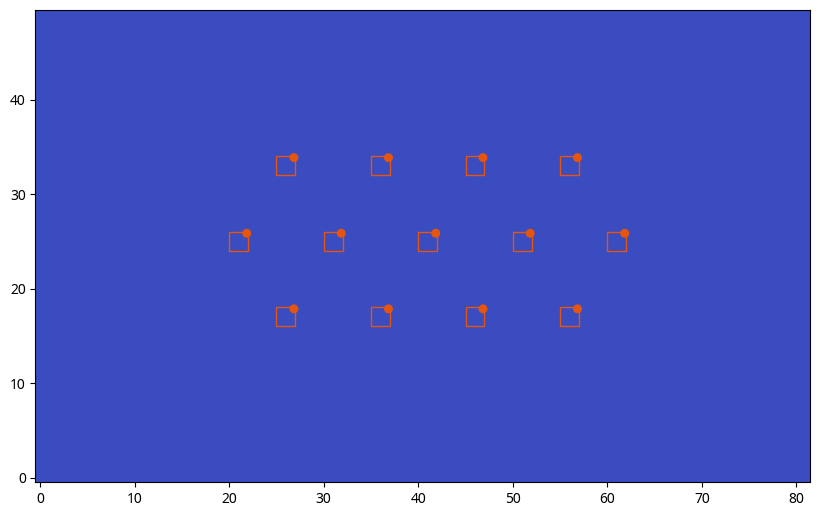

In [3]:
x0 = 0   #nm
y0 = 0    #nm
xs = 250   #nm
az_x = 500 #nm
az_y = 400 #nm
azpos = {'1':  [x0,           y0       ],
         '2':  [x0-az_x,      y0       ],
         '3':  [x0+az_x,      y0       ],
         '4':  [x0-xs,        y0-az_y  ],
         '5':  [x0+xs,        y0+az_y  ],
         '6':  [x0-xs,        y0+az_y  ],
         '7':  [x0+xs,        y0-az_y  ],
         '8':  [x0-2*az_x,    y0       ],
         '9':  [x0+2*az_x,    y0       ],
         '10': [x0-az_x-xs,   y0-az_y  ],
         '11': [x0+az_x+xs,   y0+az_y  ],
         '12': [x0+az_x+xs,   y0-az_y  ],
         '13': [x0-az_x-xs,   y0+az_y  ],
         '14': [x0,           y0-2*az_y],
         '15': [x0,           y0+2*az_y],
         '16': [x0-az_x,      y0-2*az_y],
         '17': [x0+az_x,      y0+2*az_y],
         '18': [x0-az_x,      y0+2*az_y],
         '19': [x0+az_x,      y0-2*az_y],
         '20': [x0-3*az_x,    y0       ],
         '21': [x0+3*az_x,    y0       ],
         '22': [x0-2*az_x-xs, y0-az_y  ],
         '23': [x0+2*az_x+xs, y0+az_y  ],
         '24': [x0-2*az_x-xs, y0+az_y  ],
         '25': [x0+2*az_x+xs, y0-az_y  ],
         '26': [x0-2*az_x,    y0-2*az_y],
         '27': [x0+2*az_x,    y0+2*az_y],
         '28': [x0-2*az_x,    y0+2*az_y],
         '29': [x0+2*az_x,    y0-2*az_y],
         '30': [x0-3*az_x,    y0-2*az_y],
         '31': [x0+3*az_x,    y0+2*az_y],
         '32': [x0-3*az_x,    y0+2*az_y],
         '33': [x0+3*az_x,    y0-2*az_y],
         '34': [x0-3*az_x-xs, y0+az_y  ],
         '35': [x0+3*az_x+xs, y0-az_y  ]
        }

def getAZgrid(d, ssize, plot=False):
    azsize, e = 0.1, 1e-5 # um
    xlim, ylim, zlim = [-2.05, 2.05], [-1.25, 1.25], [-0.4, 0.4]
    gridLim = np.array([xlim[0]+e, ylim[0]+e])
    
    nAZ = int(getSimInfo(d, 'nAZ'))
    azp = np.array(list(azpos.values())[:nAZ])*1e-3
    
    dVDCC = int(getSimInfo(d, 'dVAZ'))
    shift = dVDCC*1e-3/np.sqrt(2)
    
    grid = (int(np.ceil((xlim[1] - xlim[0])/ssize)), 
            int(np.ceil((ylim[1] - ylim[0])/ssize)))
    azgrid = np.zeros(grid)
    
    xyaz =   np.array((azp - gridLim - azsize/2)/ssize)
    xyvdcc = np.array((azp - gridLim + [shift, shift])/ssize)
    #print(xyvdcc)
    
    if plot:
        f, ax = plt.subplots(figsize=(10,10))
        ax.imshow(azgrid.T, cmap='coolwarm')
        ax.invert_yaxis()
        
        for xy in xyaz:
            # AZ
            ax.add_patch(patches.Rectangle(xy, azsize/ssize, azsize/ssize, 
                                           edgecolor=cpdark[1], fill=False))
        for xy in xyvdcc:
            # VDCC Cluster
            ax.add_patch(patches.Circle(xy, 0.02/ssize, edgecolor=cpdark[1], 
                                        facecolor=cpdark[1], fill=True))
            
        #ax.grid()
        
    return xyaz, xyvdcc

azgrid = getAZgrid(dirs[11], 0.05, plot=True)

In [4]:
def getCaCount(simdir, dataPath, resultPath, afi, step=0.05):
    """
    step: individual cell size in um
    timepoint in nano second

    Generate grid to store calcium ion count
    grid   := [nx, ny, nz]
    caGrid := {camol: grid}
    cbGrid := {cbmol: grid}
    """

    ISI = int(getSimInfo(simdir, 'ISI'))*1000 # in number of steps
    nstim = int(getSimInfo(simdir, 'nAP'))
    naz = int(getSimInfo(simdir, 'nAZ'))
    
    cbMolName = ['M0', 'M1', 'M2', 'H0', 'H1', 'H2']
    caMolName = ['Ca{}'.format(i) for i in range(naz+1)]
        
    xlim, ylim, zlim = [-2.05, 2.05], [-1.25, 1.25], [-0.4, 0.4]

    
    grid = (int(np.ceil((xlim[1] - xlim[0])/step)), int(np.ceil((ylim[1] - ylim[0])/step)),
                int(np.ceil((zlim[1] - zlim[0])/step)))
    
    caGrid = {}
    for camol in caMolName:
        caGrid.update({camol: np.zeros(grid)})
    #print(caGrid.keys())
    
    cbGrid = {}
    for cbmol in cbMolName:
        cbGrid.update({cbmol: np.zeros(grid)})
    #print(cbGrid.keys())
    
    seeds = [a for a in getDirs(os.path.join(dataPath, simdir), sstr='s_')]
    nseeds = len(seeds)
    #print(seeds, len(seeds))
    
    for seed in seeds:
        afiles = os.listdir(os.path.join(dataPath, simdir, seed, 'viz'))
        afiles.sort(key=natural_keys)
        af = afiles[afi]

        ff = os.path.join(dataPath, simdir, seed, 'viz', af)
        df = pd.read_table(ff, delim_whitespace=True, usecols=(0,2,3,4), 
                           names=('name', 'x', 'y', 'z'))
        
        cadata = {camol: np.array(df[df['name'] == camol][['x','y','z']]) for camol in caMolName}
        #print(cadata)

        cbdata = {cbmol: np.array(df[df.name.str.contains(cbmol)][['x','y','z']]) for cbmol in cbMolName}
        #print(cbdata)

        e = 0.0001
        gridLim = np.array([xlim[0]+e, ylim[0]+e, zlim[0]+e])
        caboxidx = {camol: np.array(np.floor((cadata[camol] - gridLim)/step), dtype='int') for camol in caMolName}
        cbboxidx = {cbmol: np.array(np.floor((cbdata[cbmol] - gridLim)/step), dtype='int') for cbmol in cbMolName}

        for camol in caMolName:
            for xid, yid, zid in caboxidx[camol]:
                caGrid[camol][xid][yid][zid] += 1
                
        for cbmol in cbMolName:
            for xid, yid, zid in cbboxidx[cbmol]:
                cbGrid[cbmol][xid][yid][zid] += 1


    for camol in caMolName:
        caGrid[camol] *= 0.00166*np.power(step, -3)/nseeds
    for cbmol in cbMolName:
        cbGrid[cbmol] *= 0.00166*np.power(step, -3)/nseeds


    if not os.path.exists(os.path.join(resultPath,simdir)):
        os.makedirs(os.path.join(resultPath,simdir))

    
    cafile = 'caGrid_tp_{}_step_{:0.2f}.dat'.format(af.split('.')[2], step)
    with open(os.path.join(resultPath, simdir, cafile),"wb") as outfile:
                    pk.dump(caGrid, outfile)
    
    cbfile = 'cbGrid_tp_{}_step_{:0.2f}.dat'.format(af.split('.')[2], step)
    with open(os.path.join(resultPath, simdir, cbfile),"wb") as outfile:
        pk.dump(cbGrid, outfile)

    return caGrid, cbGrid


### Populate mol number in boxes

In [4]:
designs = getDirs(muCa_data, sstr='nVDCC')
design = designs[0]
design

'nVDCC_3_dVDCC_60_nAZ_7_ISI_20_nAP_10'

In [4]:
xlim, ylim, zlim = [-2.05, 2.05], [-1.25, 1.25], [-0.4, 0.4]
box_dim = []

def surface_plot(arg, trials=500, step=0.1):
    """
    Returns [Ca] in each voxel (uM)
    """
    design, data_file = arg
    mol_data_path = os.path.join(muCa_data, design, data_file)
    tpoint = data_file.split('.')[2]
    try: 
        mol_data = pd.read_csv(mol_data_path, sep=' ', names=['mol','x','y','z'])
        # cb_data = mol_data[mol_data.mol.str.contains('cb')]
        ca_data = mol_data[mol_data.mol.str.contains('Ca')]
    except FileNotFoundError:
        print(f"Error: {mol_data_path}")
        return None
    
    grid = (int(np.ceil((xlim[1] - xlim[0])/step)), 
            int(np.ceil((ylim[1] - ylim[0])/step)),
            int(np.ceil((zlim[1] - zlim[0])/step)))

    caGrid_n = np.zeros(grid)
    # cbGrid = np.zeros(grid)
    # print(grid)

    e = 0.0001
    gridLim = np.array([xlim[0]+e, ylim[0]+e, zlim[0]+e])
    
    ca_vox_id = np.array(np.floor((ca_data.iloc[:,1:4] - gridLim)/step), dtype='int')
    # cb_vox_id = np.array(np.floor((cb_data.iloc[:,1:4] - gridLim)/step), dtype='int')
    
    for xid, yid, zid in ca_vox_id:
        caGrid_n[xid][yid][zid] += 1

    caGrid = caGrid_n*1.66/1e3/step**3/trials 
    with open(os.path.join(muCa_data, design, f'caGrid_tpoint_{tpoint}_step_{step:0.2f}.pkl'), "wb") as outfile:
        pk.dump(caGrid, outfile)
   
    return caGrid

caGrid = surface_plot([design, 'mfb.ascii.000100.dat'], trials=500, step=0.05)
caGrid.shape, np.min(caGrid), np.max(caGrid), caGrid[:,:,0]

Error: /media/nishant/data/output/MFB/control_eachCa/nVDCC_3_dVAZ_60_nAZ_9_RRP_20_ISI_20_nAP_10/mfb.ascii.000100.dat


AttributeError: 'NoneType' object has no attribute 'shape'

In [7]:
for design in designs[:1]:
    print(design)
    files = np.sort([f for f in os.listdir(os.path.join(muCa_data, design)) if 'ascii' in f])
    n_files = len(files)

    for file in tq(files):
        # print(file)
        surface_plot([design, file], trials=500, step=0.05)
        surface_plot([design, file], trials=500, step=0.1)


    # args = list(zip([design]*n_files, files))
    # with mp.Pool(5) as p:
    #     p.map(surface_plot, args)

nVDCC_3_dVDCC_60_nAZ_7_ISI_20_nAP_10


  0%|          | 0/810 [00:00<?, ?it/s]

100%|██████████| 810/810 [47:55<00:00,  3.55s/it]  


In [ ]:
import matplotlib.pyplot as plt

n_fig = 2
fig, ax = plt.subplots(n_fig,figsize=(4,2*n_fig))
fig.subplots_adjust(wspace=0, hspace=0)
for i in range(n_fig):
    im = ax[i].imshow(caGrid[:,:,i].T, vmin=np.min(caGrid), vmax=np.max(caGrid), cmap='Reds')
    ax[i].axis('off')
cb = fig.colorbar(im, ax=ax.ravel().tolist(), shrink=0.5, anchor=(-0.2,0.5))

In [277]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

viridis = mpl.colormaps['viridis']
viridis(1)

(0.26851, 0.009605, 0.335427, 1.0)

In [246]:
muCa_data = '/media/nishant/data/output/MFB/control_eachCa'
design = 'nVDCC_6_dVDCC_200_nAZ_29_ISI_20_nAP_10'
tpoint = 2500 # mu sec

with open(os.path.join(muCa_data, design, f'caGrid_{tpoint:06d}_0.1.pkl'), "rb") as infile:
    caGrid_ = pk.load(infile)

caGrid_.shape, caGrid_[:,:,0]

((41, 25, 8),
 array([[0.06 , 0.062, 0.094, ..., 0.074, 0.076, 0.056],
        [0.06 , 0.068, 0.064, ..., 0.07 , 0.08 , 0.09 ],
        [0.082, 0.068, 0.09 , ..., 0.082, 0.08 , 0.084],
        ...,
        [0.1  , 0.094, 0.078, ..., 0.184, 0.17 , 0.126],
        [0.096, 0.082, 0.098, ..., 0.124, 0.126, 0.112],
        [0.084, 0.086, 0.098, ..., 0.108, 0.106, 0.102]]))

## Blender code

In [ ]:
import bpy
import numpy as np
from itertools import product

step = 0.1
xlim, ylim, zlim = [-2.05, 2.05], [-1.25, 1.25], [-0.4, 0.4]

grid = [int(np.ceil((xlim[1] - xlim[0])/step)), 
        int(np.ceil((ylim[1] - ylim[0])/step)),
        int(np.ceil((zlim[1] - zlim[0])/step))]
# print(grid)

x_id = list(range(grid[0]))
y_id = list(range(grid[1]))
z_id = list(range(grid[2]))

grid_id = list(product(x_id, y_id, z_id))

x = np.arange(*xlim, step=step)
y = np.arange(*ylim, step=step)
z = np.arange(*zlim, step=step)
# print(x, y, z, sep='\n')

x_n, y_n, z_n = 3,3,3 #grid
# x_n, y_n, z_n = grid
grid_id = list(product(x_id[:x_n], y_id[:y_n], z_id[:z_n]))
locs = np.array(list(product(x[:x_n], y[:y_n], z[:z_n])))

for gid, loc in zip(grid_id, locs):
    bpy.ops.mesh.primitive_cube_add(location=loc, scale=(step/2,step/2,step/2))
    
    cube = bpy.context.selected_objects[0]
    cube.name = 'cube_' + '_'.join([str(i) for i in gid])

    ## create new material with name of object
    mat = bpy.data.materials.new('mat_' + cube.name)
    mat.use_nodes = True
    
    ## Remove 'Surface' node
    # link = mat.node_tree.nodes['Material Output'].inputs['Surface'].links[0]
    # mat.node_tree.links.remove(link)
    nodes = mat.node_tree.nodes
    mat.node_tree.nodes.remove(nodes['Principled BSDF'])
    
    ## Create a new Shader node
    # PV_node = nodes.new('ShaderNodeVolumePrincipled')
    # PV_node.inputs['Density'].default_value = 10.0

    emission_node = nodes.new('ShaderNodeEmission')
    emission_node.inputs['Strength'].default_value = 1.0

    mat_out_node = nodes.get('Material Output')

    ## Link shader nodes to material output
    mat.node_tree.links.new(mat_out_node.inputs['Volume'], emission_node.outputs[0])
    # mat.node_tree.links.new(mat_out_node.inputs['Volume'], PV_node.outputs[0])
    
    ## add new material to object
    cube.data.materials.append(mat)



In [ ]:
import bpy
import os
import numpy as np
import pickle as pk
from itertools import product

step = 0.1
xlim, ylim, zlim = [-2.05, 2.05], [-1.25, 1.25], [-0.4, 0.4]

muCa_data = '/media/nishant/data/output/MFB/control_eachCa'
design = 'nVDCC_6_dVDCC_200_nAZ_29_ISI_20_nAP_10'
tpoint = 2500 # mu sec

with open(os.path.join(muCa_data, design, f'caGrid_{tpoint:06d}_{step}.pkl'), "rb") as infile:
    caGrid = pk.load(infile)
    caGrid = caGrid - np.min(caGrid)
# caGrid.shape, caGrid[:,:,0]
    
def make_cubes():
    grid = [int(np.ceil((xlim[1] - xlim[0])/step)), 
            int(np.ceil((ylim[1] - ylim[0])/step)),
            int(np.ceil((zlim[1] - zlim[0])/step))]
    # print(grid)

    x_id = list(range(grid[0]))
    y_id = list(range(grid[1]))
    z_id = list(range(grid[2]))

    grid_id = list(product(x_id, y_id, z_id))

    e = 0.0001
    x = [x+i*e for i,x in enumerate(np.arange(*xlim, step=step))]
    y = [y+i*e for i,y in enumerate(np.arange(*ylim, step=step))]
    z = [z+i*e for i,z in enumerate(np.arange(*zlim, step=step))]
    # print(x, y, z, sep='\n')

    x_n, y_n, z_n = 20,12,4 #grid
#    x_n, y_n, z_n = grid
    grid_id = list(product(x_id[:x_n], y_id[:y_n], z_id[:z_n]))
    locs = np.array(list(product(x[:x_n], y[:y_n], z[:z_n])))

    def make_a_cube(grid_spec, step=step):
        gid, loc = grid_spec

        bpy.ops.mesh.primitive_cube_add(location=loc, scale=(step/2,step/2,step/2))
        
        cube = bpy.context.selected_objects[0]
        cube.name = 'cube_' + '_'.join([str(i) for i in gid]
        
def remove_cube_properties():
    cubes = [bpy.data.objects[k] for k in bpy.data.objects.keys() if 'cube' in k]
    
    for cube in cubes:
        ## create new material with name of object
        mat = bpy.data.materials.new('mat_' + cube.name)
        mat.use_nodes = True
        
        ## Remove 'Surface' node
        # link = mat.node_tree.nodes['Material Output'].inputs['Surface'].links[0]
        # mat.node_tree.links.remove(link)
        nodes = mat.node_tree.nodes
        mat.node_tree.nodes.remove(nodes['Principled BSDF'])
        
        
def change_cube_properties():
    cubes = [bpy.data.objects[k] for k in bpy.data.objects.keys() if 'cube' in k]
    
    for cube in cubes:
        ## Create a new Shader node
        # PV_node = nodes.new('ShaderNodeVolumePrincipled')
        # PV_node.inputs['Density'].default_value = 10.0

        emission_node = nodes.new('ShaderNodeEmission')
        emission_node.inputs['Strength'].default_value = 1.0

        mat_out_node = nodes.get('Material Output')

        ## Link shader nodes to material output
        mat.node_tree.links.new(mat_out_node.inputs['Volume'], emission_node.outputs[0])
        # mat.node_tree.links.new(mat_out_node.inputs['Volume'], PV_node.outputs[0])
        
        ## add new material to object
        cube.data.materials.append(mat)
        
#list(map(make_a_cube, list(zip(grid_id, locs))))

In [ ]:
import numpy as np
from itertools import product

step = 0.1
xlim, ylim, zlim = [-2.05, 2.05], [-1.25, 1.25], [-0.4, 0.4]

grid = [int(np.ceil((xlim[1] - xlim[0])/step)), 
        int(np.ceil((ylim[1] - ylim[0])/step)),
        int(np.ceil((zlim[1] - zlim[0])/step))]
print(grid)
x_id = list(range(grid[0]))
y_id = list(range(grid[1]))
z_id = list(range(grid[2]))

grid_id = list(product(x_id, y_id, z_id))

e = 0.0001
x = [x+i*e for i,x in enumerate(np.arange(*xlim, step=step))]
y = [y+i*e for i,y in enumerate(np.arange(*ylim, step=step))]
z = [z+i*e for i,z in enumerate(np.arange(*zlim, step=step))]
# y = np.arange(*ylim, step=step)
# z = np.arange(*zlim, step=step)
# print(x, y, z, sep='\n')

x_n, y_n, z_n = 3,3,3 #grid
grid_id = list(product(x_id[:x_n], y_id[:y_n], z_id[:z_n]))
locs = np.array(list(product(x[:x_n], y[:y_n], z[:z_n])))

for id, loc in zip(grid_id, locs):
    print(id, loc)

In [ ]:
import bpy
import numpy as np
from itertools import product

step = 0.1
xlim, ylim, zlim = [-2.05, 2.05], [-1.25, 1.25], [-0.4, 0.4]

#######################################
def make_a_cube(grid_spec, step=step):
    gid, loc = grid_spec

    bpy.ops.mesh.primitive_cube_add(location=loc, scale=(step/2,step/2,step/2))
    
    cube = bpy.context.selected_objects[0]
    cube.name = 'cube_' + '_'.join([str(i) for i in gid])
    

#######################################
def make_cubes():
    grid = [int(np.ceil((xlim[1] - xlim[0])/step)), 
            int(np.ceil((ylim[1] - ylim[0])/step)),
            int(np.ceil((zlim[1] - zlim[0])/step))]
    # print(grid)

    x_id = list(range(grid[0]))
    y_id = list(range(grid[1]))
    z_id = list(range(grid[2]))

    grid_id = list(product(x_id, y_id, z_id))

    e = 0.0001
    x = [x+i*e for i,x in enumerate(np.arange(*xlim, step=step))]
    y = [y+i*e for i,y in enumerate(np.arange(*ylim, step=step))]
    z = [z+i*e for i,z in enumerate(np.arange(*zlim, step=step))]
    # print(x, y, z, sep='\n')

    x_n, y_n, z_n = 20,12,4 #grid
#    x_n, y_n, z_n = grid
    grid_id = list(product(x_id[:x_n], y_id[:y_n], z_id[:z_n]))
    locs = np.array(list(product(x[:x_n], y[:y_n], z[:z_n])))
    
    list(map(make_a_cube, list(zip(grid_id, locs))))

#######################################
def initialise_cube_properties():
    cubes = [obj for obj in bpy.data.objects if 'cube' in obj.name]
    
    for cube in cubes[:]:
        cid = [int(id) for id in cube.name.split('_')[1:]]
        ## create new material with name of object
        mat = bpy.data.materials.new('mat_' + cube.name)
        mat.use_nodes = True
        
        ## Remove 'Surface' node
        # link = mat.node_tree.nodes['Material Output'].inputs['Surface'].links[0]
        # mat.node_tree.links.remove(link)
        nodes = mat.node_tree.nodes
        mat.node_tree.nodes.remove(nodes['Principled BSDF'])
        
        ## Create a new Shader node
        PV_node = nodes.new('ShaderNodeVolumePrincipled')
        PV_node.inputs['Density'].default_value = 1
        PV_node.inputs['Color'].default_value = (1,0,0,1)

#        emission_node = nodes.new('ShaderNodeEmission')
#        emission_node.inputs['Strength'].default_value = 1

        mat_out_node = nodes.get('Material Output')

        ## Link shader nodes to material output
#        mat.node_tree.links.new(mat_out_node.inputs['Volume'], emission_node.outputs[0])
        mat.node_tree.links.new(mat_out_node.inputs['Volume'], PV_node.outputs[0])
        
        ## add new material to object
        cube.data.materials.append(mat)
    

make_cubes()
initialise_cube_properties()


In [ ]:
tpoints = np.concatenate([[a+i*20000 for a in list(range(0, 4001, 50))] for i in range(10)])
len(tpoints), tpoints

In [ ]:
# import bpy
import os
import numpy as np
import pickle as pk
from itertools import product

step = 0.1
design = 'nVDCC_6_dVDCC_200_nAZ_29_ISI_20_nAP_10'
xlim, ylim, zlim = [-2.05, 2.05], [-1.25, 1.25], [-0.4, 0.4]

########################################
def change_cube_properties():
    cubes = [obj for obj in bpy.data.objects if 'cube' in obj.name]

    for cube in cubes:
        cid = [int(id) for id in cube.name.split('_')[1:]]
        # PV_node = bpy.data.materials[f"mat_{cube.name}"].node_tree.nodes["Principled Volume"]
        # PV_node.inputs['Density'].default_value = caGrid[cid[0], cid[1], cid[2]]
#        PV_node.inputs['Color'].default_value = (1,0,0,1)

#########################################
# def render(tpoint):
#     scene = bpy.context.scene
#     scene.render.filepath = f"/home/nishant/lab/MFB/plots/ca_overlap/{design}_{tpoint}.png"
#     bpy.ops.render.render(write_still=True)
    
    
def make_it_happen(tpoint):
    ## Get calcium concentration into caGrid
    muCa_data = '/media/nishant/data/output/MFB/control_eachCa'
    
    fname = f'caGrid_tpoint_{tpoint:06d}_step_{step:0.02f}.pkl'
    with open(os.path.join(muCa_data, design, fname), "rb") as infile:
        caGrid = pk.load(infile)
        
    change_cube_properties()
#    render()
##########################################    
    
tpoints = np.concatenate([[a+i*20000 for a in list(range(0, 4001, 50))] for i in range(10)])
tpoints = tpoints[:2]
for tpoint in tpoints:
    make_it_happen(tpoint)

## Create gif from images


In [ ]:
from PIL import Image, ImageDraw, ImageFont

def all_same(v):
    return v.count(v[0]) == len(v)

def concat_images(images, orientation='v'):
    widths, heights = zip(*(i.size for i in images))
    assert all_same(widths), "Not all images have equal width"
    assert all_same(heights), "Not all images have equal height"

    n = len(images)
    if orientation == 'v':
        img = Image.new('RGB', (widths[0], sum(heights)))

        for i in range(n):
            img.paste(images[i], (0, i*heights[0]))
    
    elif orientation == 'h':
        img = Image.new('RGB', (sum(widths), heights[0]))
    
        for i in range(n):
            img.paste(images[i], (i*widths[0], 0))

    return img

def create_gif(images, output, duration=50):
    """
    images: list of PIL images
    output: path to save the gif
    duration: duration of each frame in milliseconds
    """
    # Save as GIF
    images[0].save(output,
        save_all=True,
        format="GIF",
        append_images=images[1:],
        duration=duration,
        loop=0 # 0 means infinite loop
    )

def add_text_in_image(images, text, loc=(10,10), fontsize=25, color=(0,0,0), font='arial.ttf'):
    font = ImageFont.truetype('arial.ttf', fontsize)

    for txt,img in zip(text,images):
        ImageDraw.Draw(img).text(loc, f'{txt}', color, font=font)

def make_gif(design, AP=[0,4,9], step=0.1, output=None, fps=20, orientation='v'):
    image_dir = '../plots/ca_overlap/'

    tpoints = np.array([[a+i*20000 for a in list(range(0, 4001, 50))] for i in AP]).T
    # print(len(tpoints[0]), tpoints)

    images = []
    for tps in tpoints:
        try:
            imgs = [Image.open(os.path.join(image_dir, design, f'{tp:06d}.png')) for tp in tps]
        except FileNotFoundError:
            print(tps)
            continue
        add_text_in_image(imgs, [ap+1 for ap in AP], loc=(15,15),
                          color=(200,200,200))
        add_text_in_image(imgs, [f'{tp/1000:0.02f} ms' for tp in tps], fontsize=17, 
                          loc=(imgs[0].width-85,10), color=(200,200,200))
        images.append(concat_images(imgs))
        # images[0].show(); break

    if not output:
        output = os.path.join(figPath, f'{design}_step_{step:0.02f}.gif')

    duration = 1000/fps
    create_gif(images[:81], output, duration=duration)

    
make_gif('nVDCC_6_dVDCC_200_nAZ_29_ISI_20_nAP_10', AP=[0,4,9], fps=10)

In [28]:
tpoints = np.concatenate([[a+i*20000 for a in list(range(0, 4001, 50))] for i in range(10)])
tpoints[300]


62850